# Task 3: Heart Disease Prediction

Objective: Build a model to predict whether a person is at risk of heart disease based on health data.

**Dataset:** UCI Heart Disease dataset which has been loaded directly (no Kaggle download needed).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, roc_auc_score
)

print('Libraries imported!')

Libraries imported!


## Step 1: Load the Dataset

We load the UCI Heart Disease dataset directly from the UCI ML Repository; no Kaggle account needed.

In [2]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'

col_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
    'restecg', 'thalach', 'exang', 'oldpeak', 'slope',
    'ca', 'thal', 'target'
]

df = pd.read_csv(url, names=col_names, na_values='?')

# Binarize target: 0 = no disease, 1 = disease
df['target'] = (df['target'] > 0).astype(int)

print(f'Shape: {df.shape}')
print(f'Missing values per column:\n{df.isnull().sum()}')
df.head()

Shape: (303, 14)
Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## Step 2: Data Cleaning

In [3]:
# Handle missing values by filling with column median
df.fillna(df.median(numeric_only=True), inplace=True)

print('Missing values after cleaning:')
print(df.isnull().sum())
print()
print('Descriptive statistics:')
df.describe()

Missing values after cleaning:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Descriptive statistics:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.663366,4.722772,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,1.938383,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


## Step 3: Exploratory Data Analysis (EDA)

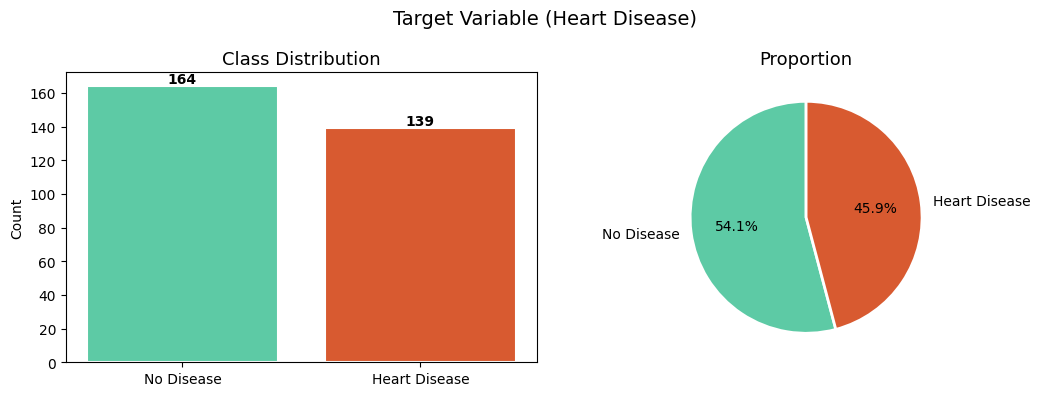

In [4]:
# Target class distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

counts = df['target'].value_counts()
labels = ['No Disease', 'Heart Disease']
colors = ['#5DCAA5', '#D85A30']

ax1.bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.5)
ax1.set_title('Class Distribution', fontsize=13)
ax1.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax1.text(i, v + 2, str(v), ha='center', fontweight='bold')

ax2.pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
        startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax2.set_title('Proportion', fontsize=13)

plt.suptitle('Target Variable (Heart Disease)', fontsize=14)
plt.tight_layout()
plt.show()

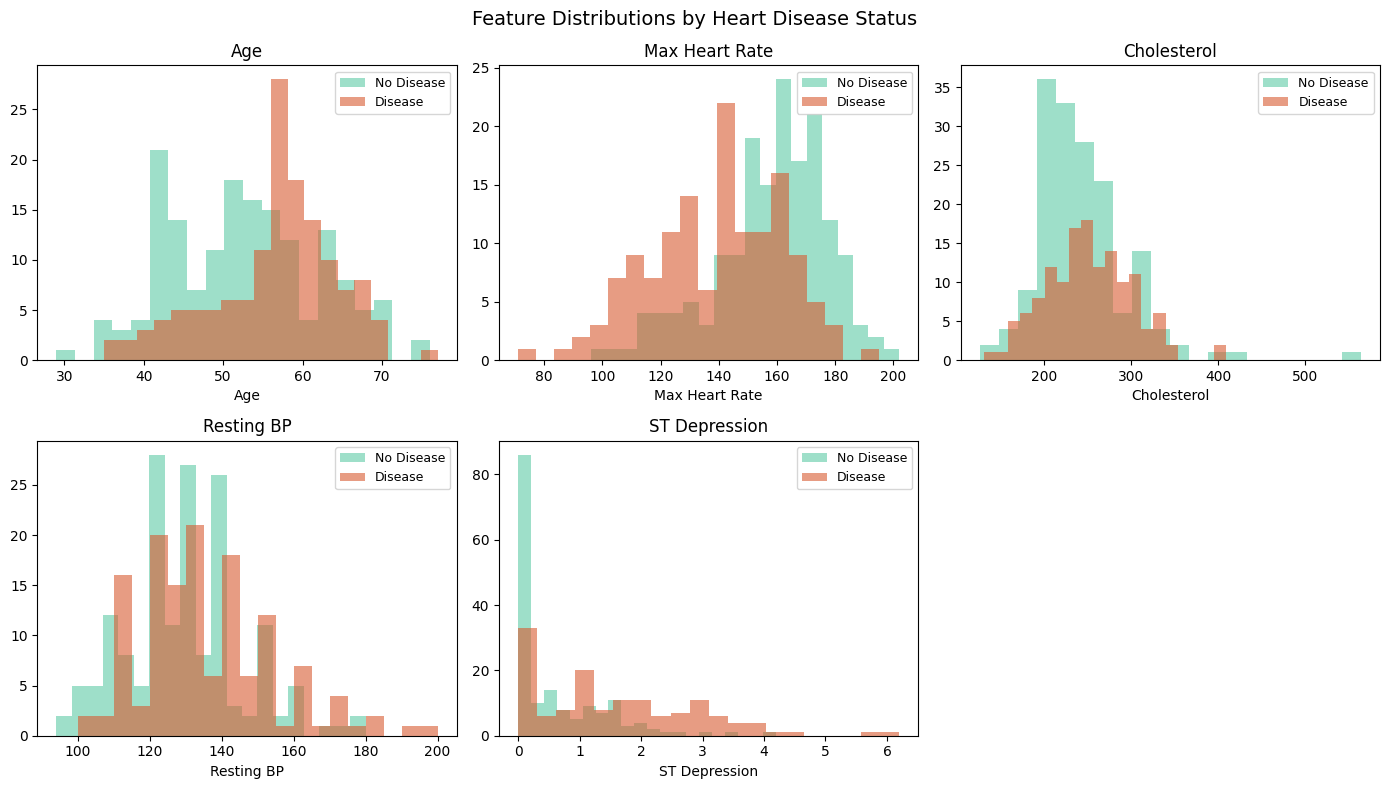

In [5]:
# Key feature distributions by target
key_features = ['age', 'thalach', 'chol', 'trestbps', 'oldpeak']
feature_labels = ['Age', 'Max Heart Rate', 'Cholesterol', 'Resting BP', 'ST Depression']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, (feat, label) in enumerate(zip(key_features, feature_labels)):
    for val, name, color in [(0, 'No Disease', '#5DCAA5'), (1, 'Disease', '#D85A30')]:
        axes[i].hist(df[df['target']==val][feat], bins=20,
                     alpha=0.6, label=name, color=color)
    axes[i].set_title(label)
    axes[i].legend(fontsize=9)
    axes[i].set_xlabel(label)

axes[-1].axis('off')
plt.suptitle('Feature Distributions by Heart Disease Status', fontsize=14)
plt.tight_layout()
plt.show()

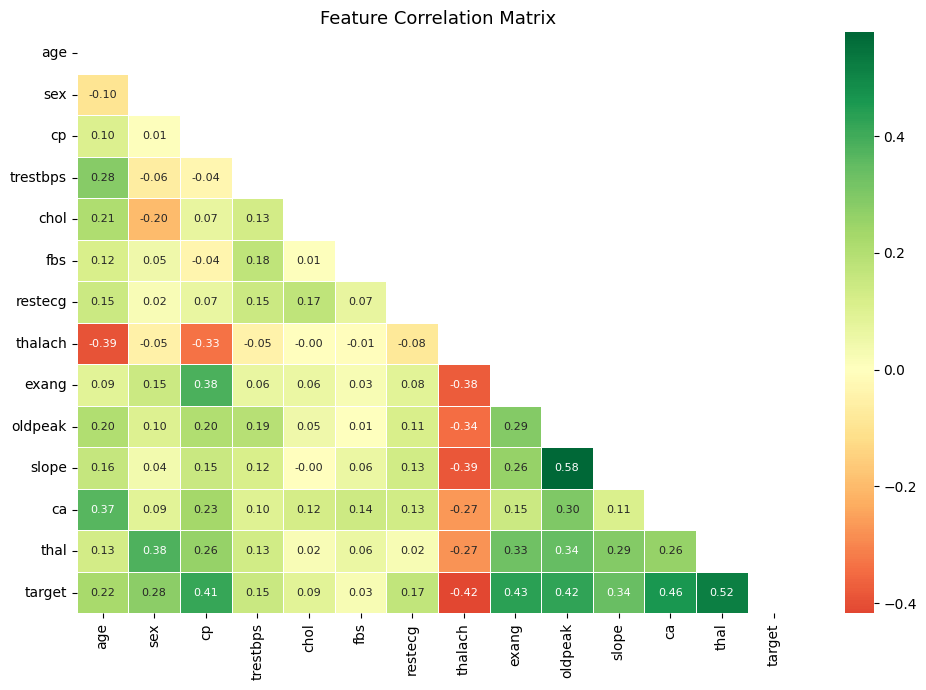

In [6]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

## Step 4: Prepare Features for Modeling

In [7]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train size: {len(X_train)}, Test size: {len(X_test)}')

Train size: 242, Test size: 61


## Step 5: Train Classification Models

In [8]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)
y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]

# Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_sc, y_train)
y_pred_dt = dt.predict(X_test_sc)
y_prob_dt = dt.predict_proba(X_test_sc)[:, 1]

print('Logistic Regression Accuracy:', accuracy_score(y_test, y_pred_lr))
print('Decision Tree Accuracy:       ', accuracy_score(y_test, y_pred_dt))

Logistic Regression Accuracy: 0.8688524590163934
Decision Tree Accuracy:        0.7704918032786885


## Step 6: Evaluate — Confusion Matrix, ROC Curve, Classification Report

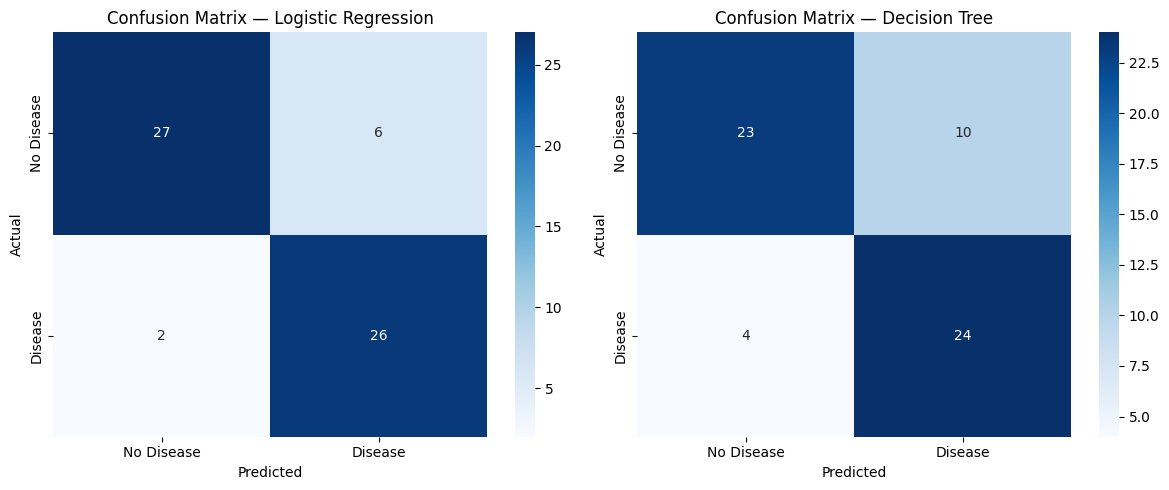

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title in zip(axes,
                              [y_pred_lr, y_pred_dt],
                              ['Logistic Regression', 'Decision Tree']):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'])
    ax.set_title(f'Confusion Matrix — {title}', fontsize=12)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

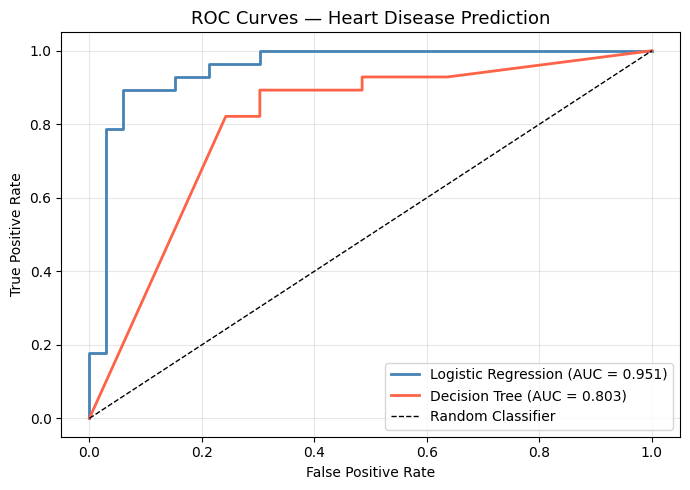

In [10]:
# ROC Curves
plt.figure(figsize=(7, 5))

for probs, name, color in [
    (y_prob_lr, 'Logistic Regression', 'steelblue'),
    (y_prob_dt, 'Decision Tree',       'tomato')
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color, linewidth=2)

plt.plot([0,1],[0,1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Heart Disease Prediction', fontsize=13)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
print('LOGISTIC REGRESSION — Classification Report')
print('='*50)
print(classification_report(y_test, y_pred_lr, target_names=['No Disease', 'Disease']))

print('DECISION TREE — Classification Report')
print('='*50)
print(classification_report(y_test, y_pred_dt, target_names=['No Disease', 'Disease']))

LOGISTIC REGRESSION — Classification Report
              precision    recall  f1-score   support

  No Disease       0.93      0.82      0.87        33
     Disease       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61

DECISION TREE — Classification Report
              precision    recall  f1-score   support

  No Disease       0.85      0.70      0.77        33
     Disease       0.71      0.86      0.77        28

    accuracy                           0.77        61
   macro avg       0.78      0.78      0.77        61
weighted avg       0.78      0.77      0.77        61



## Step 7: Feature Importance Analysis

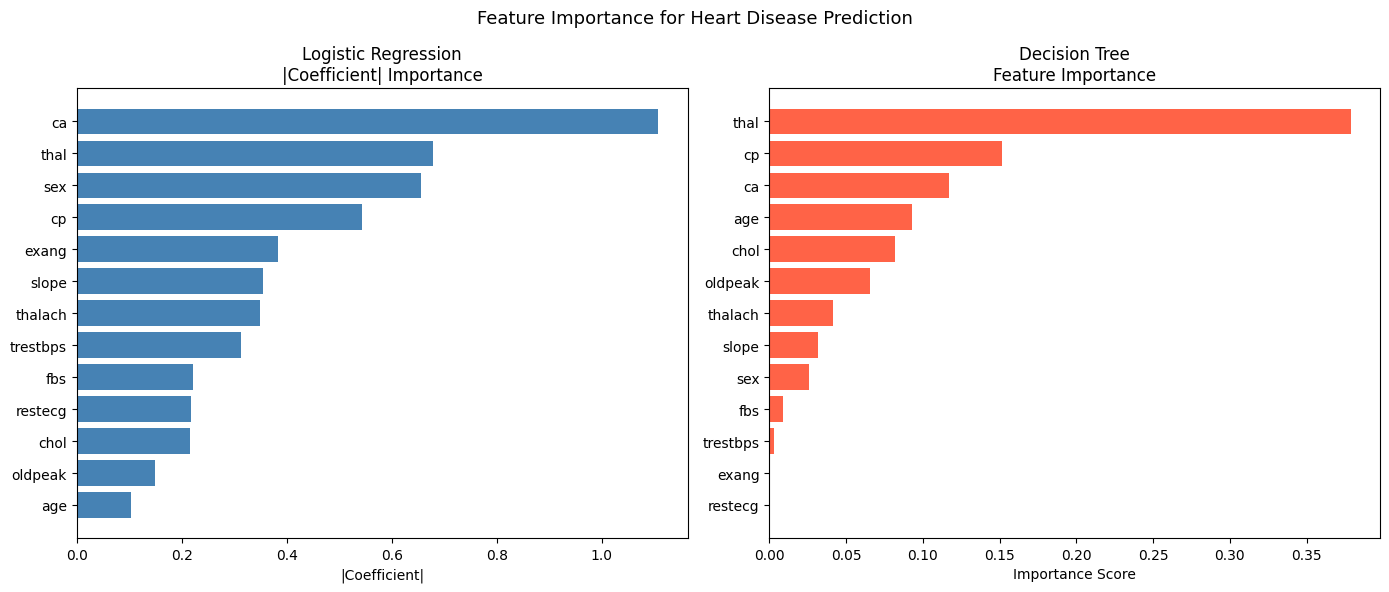


Top 3 features (Logistic Regression):
Feature  Coefficient
    sex     0.655563
   thal     0.677821
     ca     1.107898

Top 3 features (Decision Tree):
Feature  Importance
     ca    0.116874
     cp    0.151595
   thal    0.378859


In [12]:
# Logistic Regression — coefficient magnitudes
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': np.abs(lr.coef_[0])
}).sort_values('Coefficient')

# Decision Tree — feature importances
imp_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt.feature_importances_
}).sort_values('Importance')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.barh(coef_df['Feature'], coef_df['Coefficient'], color='steelblue')
ax1.set_title('Logistic Regression\n|Coefficient| Importance', fontsize=12)
ax1.set_xlabel('|Coefficient|')

ax2.barh(imp_df['Feature'], imp_df['Importance'], color='tomato')
ax2.set_title('Decision Tree\nFeature Importance', fontsize=12)
ax2.set_xlabel('Importance Score')

plt.suptitle('Feature Importance for Heart Disease Prediction', fontsize=13)
plt.tight_layout()
plt.show()

print('\nTop 3 features (Logistic Regression):')
print(coef_df.tail(3)[['Feature', 'Coefficient']].to_string(index=False))

print('\nTop 3 features (Decision Tree):')
print(imp_df.tail(3)[['Feature', 'Importance']].to_string(index=False))

## Summary

| Feature | Meaning |
|---------|----------|
| **thalach** | Maximum heart rate achieved |
| **cp** | Chest pain type |
| **oldpeak** | ST depression induced by exercise |
| **ca** | Number of major vessels colored by fluoroscopy |
| **thal** | Thalassemia blood disorder type |

These features tend to be the most predictive for heart disease risk.